# 02. EDA → Feature Selection → Feature Engineering

This notebook has three sequential parts:

**Part A — Exploratory Data Analysis**  
Understand distributions, relationships, and quirks of the cleaned data before touching any model.

**Part B — Feature Selection**  
Use EDA findings, correlation analysis, and preliminary importance scores to select a parsimonious, model-ready covariate set.

**Part C — Feature Engineering**  
Build the final modeling dataset: derive new features, construct treatment variables, encode categoricals, and save `accepted_modeling.parquet` for Notebooks 03–05.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder

from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

os.chdir("C:/Users/David Cho/OneDrive/Desktop/Projects/credit-risk-causal-analysis")

In [3]:
DATA_DIR   = './outputs/intermediate'

df = pd.read_parquet(f'{DATA_DIR}/accepted_cleaned.parquet')

In [4]:
df.columns

Index(['id', 'loan_amnt', 'funded_amnt', 'term', 'int_rate', 'grade',
       'sub_grade', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose',
       'addr_state', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high',
       'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec',
       'revol_bal', 'revol_util', 'total_acc', 'application_type',
       'issue_year', 'term_months', 'emp_length_num', 'fico_mid',
       'ever_delinq', 'annual_inc_cap'],
      dtype='str')

In [5]:
print(df['loan_status'].value_counts(dropna=False).sort_values(ascending=False))

loan_status
Fully Paid     819855
Charged Off    206115
Default            12
Name: count, dtype: int64


In [6]:
# Create outcome variable here for EDA (used throughout Part A)
DEFAULT_STATUS = ['Charged Off', 'Default']
df['default'] = df['loan_status'].isin(DEFAULT_STATUS).astype(int)

print(f'Dataset: {df.shape}')
print(f'Default rate : {df["default"].mean():.4f}  ({df["default"].sum():,} defaults)')

Dataset: (1025982, 34)
Default rate : 0.2009  (206,127 defaults)


---
# Part A — Exploratory Data Analysis

## A1. Raw Relationship — Interest Rate vs. Default Rate

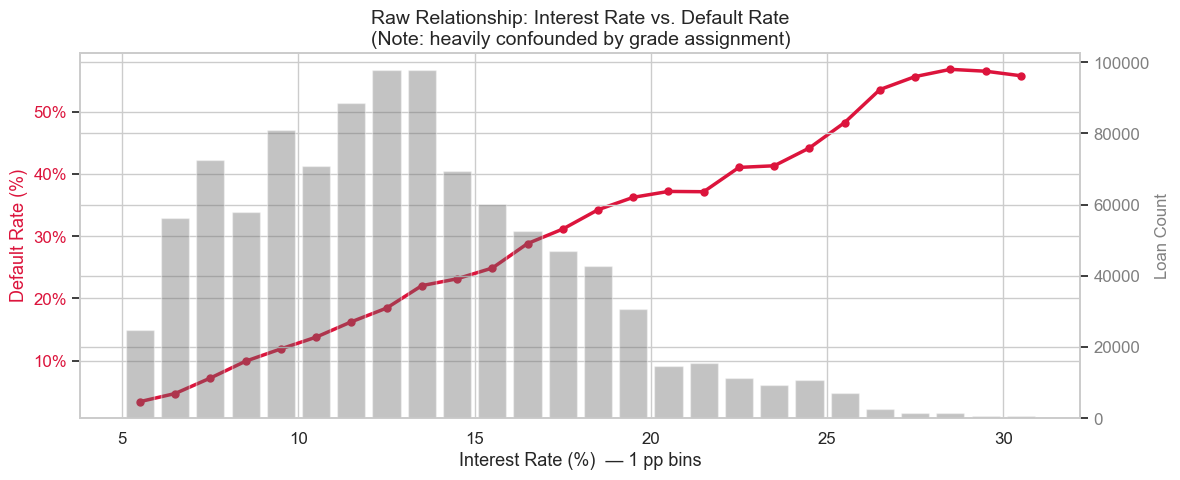

Pearson r(int_rate, default) = 0.2651  [raw, confounded]


In [9]:
FIGURE_DIR  = './outputs/figures'

df['int_rate_bin'] = pd.cut(df['int_rate'], bins=np.arange(5, 32, 1), right=False)
binned = (
    df.groupby('int_rate_bin', observed=True)
    .agg(n=('default','count'), default_rate=('default','mean'))
    .reset_index()
)
binned['mid'] = binned['int_rate_bin'].apply(lambda x: x.mid)
binned = binned[binned['n'] >= 100]

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax2.bar(binned['mid'], binned['n'], width=0.8, color='dimgrey', alpha=0.4, label='Loan Count')
ax2.set_ylabel('Loan Count', color='grey', fontsize=12)
ax2.tick_params(axis='y', labelcolor='grey')

ax1.plot(binned['mid'], binned['default_rate']*100,
         color='crimson', linewidth=2.5, marker='o', markersize=5)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_xlabel('Interest Rate (%)  — 1 pp bins', fontsize=13)
ax1.set_ylabel('Default Rate (%)', color='crimson', fontsize=13)
ax1.tick_params(axis='y', labelcolor='crimson')
ax1.set_title('Raw Relationship: Interest Rate vs. Default Rate\n'
              '(Note: heavily confounded by grade assignment)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig04_int_rate_vs_default_raw.png', dpi=150, bbox_inches='tight')
plt.show()

r = df[['int_rate','default']].corr().loc['int_rate','default']
print(f'Pearson r(int_rate, default) = {r:.4f}  [raw, confounded]')

## A2. Default Rate by Grade

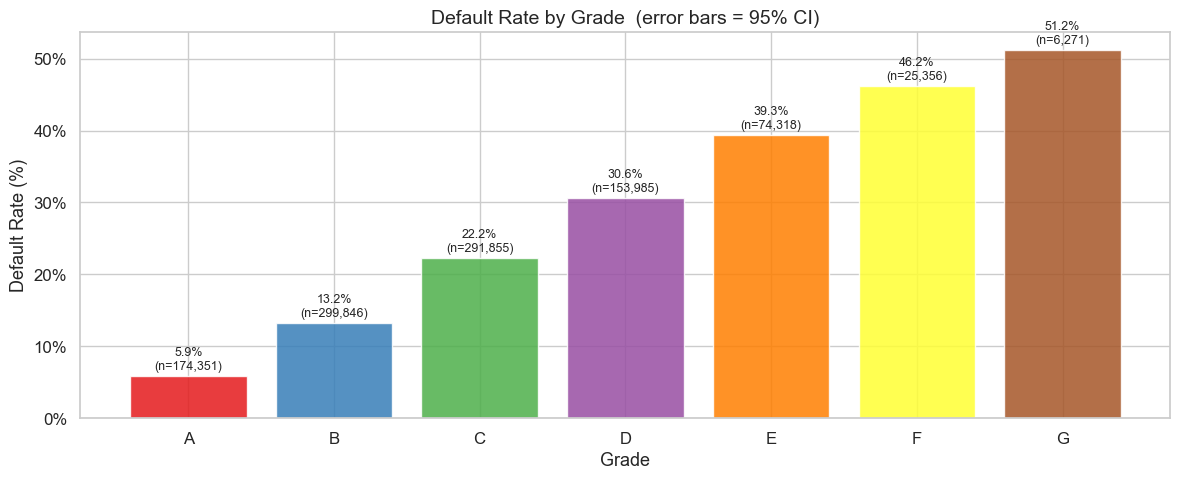

In [11]:
GRADE_ORDER   = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
GRADE_PALETTE = sns.color_palette('Set1', n_colors=7)

grade_stats = (
    df.groupby('grade')
    .agg(n=('default','count'), default_rate=('default','mean'),
         se=('default', lambda x: x.std() / np.sqrt(len(x))))
    .loc[GRADE_ORDER]
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    GRADE_ORDER, grade_stats['default_rate'] * 100,
    color=GRADE_PALETTE, alpha=0.85, capsize=5, edgecolor='white'
)
for bar, (_, row) in zip(bars, grade_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{row["default_rate"]*100:.1f}%\n(n={int(row["n"]):,})',
            ha='center', va='bottom', fontsize=9)

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Grade', fontsize=13); ax.set_ylabel('Default Rate (%)', fontsize=13)
ax.set_title('Default Rate by Grade  (error bars = 95% CI)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig02_grade_default_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## A3. Interest Rate Distribution by Grade

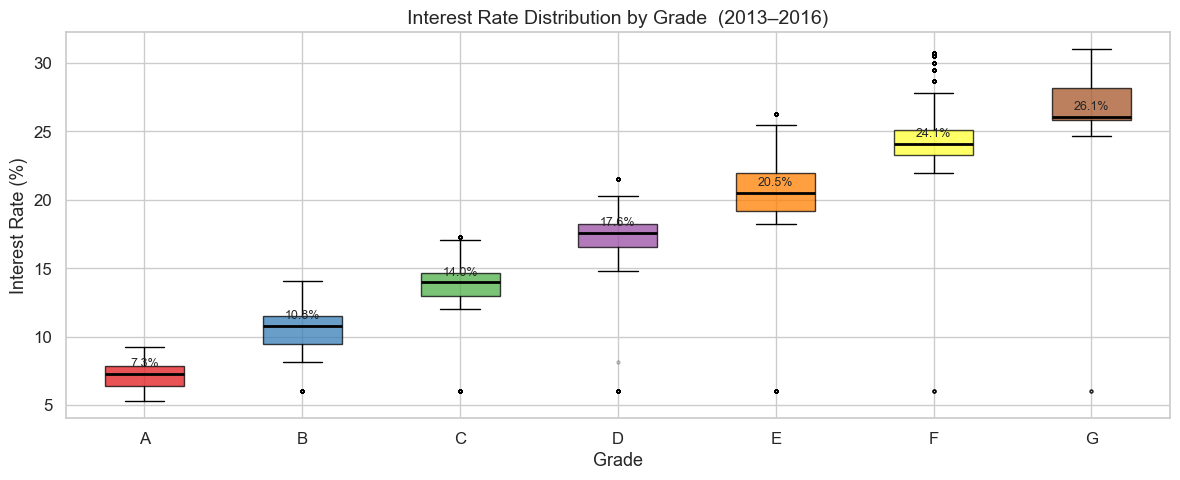

          count   mean   std   min    25%    50%    75%    max
grade                                                         
A      174351.0   7.10  1.00  5.32   6.39   7.26   7.89   9.25
B      299846.0  10.58  1.37  6.00   9.49  10.78  11.49  14.09
C      291855.0  13.91  1.21  6.00  12.99  13.98  14.65  17.27
D      153985.0  17.48  1.36  6.00  16.55  17.57  18.25  21.49
E       74318.0  20.62  1.86  6.00  19.19  20.49  21.97  26.24
F       25356.0  24.43  1.65  6.00  23.28  24.08  25.09  30.74
G        6271.0  27.04  1.67  6.00  25.83  26.06  28.18  30.99


In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

grade_data = [df.loc[df['grade'] == g, 'int_rate'].values for g in GRADE_ORDER]
bp = ax.boxplot(
    grade_data, labels=GRADE_ORDER, patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
for patch, color in zip(bp['boxes'], GRADE_PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.75)

for i, g in enumerate(GRADE_ORDER):
    med = df[df['grade'] == g]['int_rate'].median()
    ax.text(i + 1, med + 0.3, f'{med:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Grade', fontsize=13)
ax.set_ylabel('Interest Rate (%)', fontsize=13)
ax.set_title('Interest Rate Distribution by Grade  (2013–2016)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig01_grade_int_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print(df.groupby('grade')['int_rate'].describe().round(2))

## A4. Interest Rate Distribution — Overall

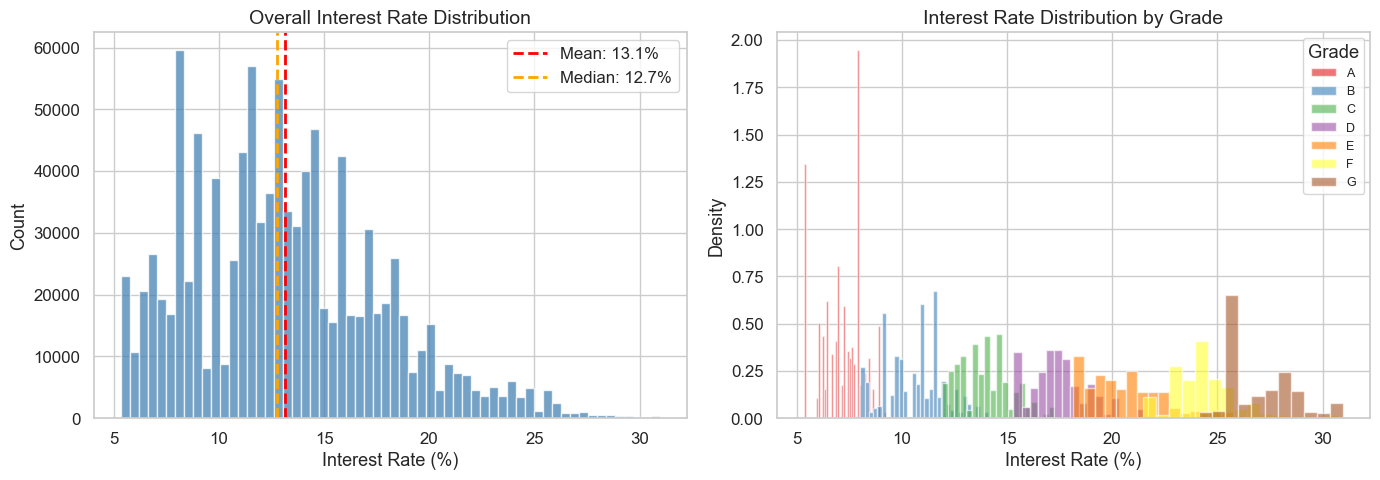

Key percentiles:
count    1025982.00
mean          13.14
std            4.61
min            5.32
10%            7.49
25%            9.67
50%           12.74
75%           15.80
90%           19.19
max           30.99
Name: int_rate, dtype: float64


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df['int_rate'], bins=60, color='steelblue', alpha=0.75, edgecolor='white')
ax.axvline(df['int_rate'].mean(),   color='red',    linestyle='--', linewidth=2,
           label=f'Mean: {df["int_rate"].mean():.1f}%')
ax.axvline(df['int_rate'].median(), color='orange', linestyle='--', linewidth=2,
           label=f'Median: {df["int_rate"].median():.1f}%')
ax.set_xlabel('Interest Rate (%)', fontsize=13); ax.set_ylabel('Count', fontsize=13)
ax.set_title('Overall Interest Rate Distribution', fontsize=14); ax.legend()

ax = axes[1]
for g, color in zip(GRADE_ORDER, GRADE_PALETTE):
    ax.hist(df[df['grade'] == g]['int_rate'], bins=40, alpha=0.6,
            color=color, label=g, density=True)
ax.set_xlabel('Interest Rate (%)', fontsize=13); ax.set_ylabel('Density', fontsize=13)
ax.set_title('Interest Rate Distribution by Grade', fontsize=14)
ax.legend(title='Grade', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig03_int_rate_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key percentiles:')
print(df['int_rate'].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]).round(2))

## A5. Interest Rate and Default Across All Sub-Grades

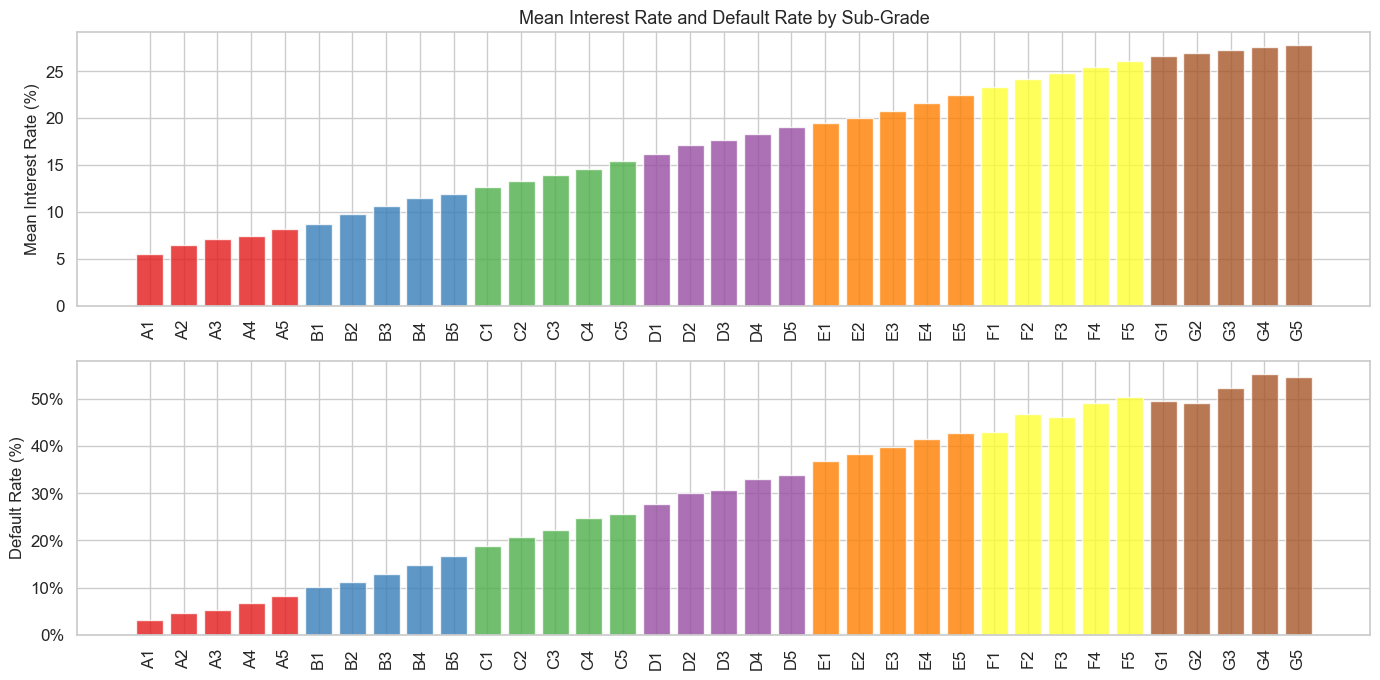

In [17]:
SUBGRADE_ORDER = [f'{g}{n}' for g in GRADE_ORDER for n in range(1, 6)]
sg_stats = (
    df.groupby('sub_grade')
    .agg(n=('default','count'), default_rate=('default','mean'),
         mean_int_rate=('int_rate','mean'))
    .loc[[s for s in SUBGRADE_ORDER if s in df['sub_grade'].unique()]]
)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
for ax_idx, (metric, ylabel) in enumerate([
    ('mean_int_rate', 'Mean Interest Rate (%)'),
    ('default_rate',  'Default Rate (%)')
]):
    ax = axes[ax_idx]
    colors = [GRADE_PALETTE[GRADE_ORDER.index(sg[0])] for sg in sg_stats.index]
    vals   = sg_stats[metric] * (100 if metric == 'default_rate' else 1)
    ax.bar(range(len(sg_stats)), vals, color=colors, alpha=0.8, edgecolor='white')
    ax.set_xticks(range(len(sg_stats)))
    ax.set_xticklabels(sg_stats.index, rotation=90, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    if metric == 'default_rate':
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())

axes[0].set_title('Mean Interest Rate and Default Rate by Sub-Grade', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig06_subgrade_rate_default.png', dpi=150, bbox_inches='tight')
plt.show()

## A6. Interest Rate vs. Default by Loan Term

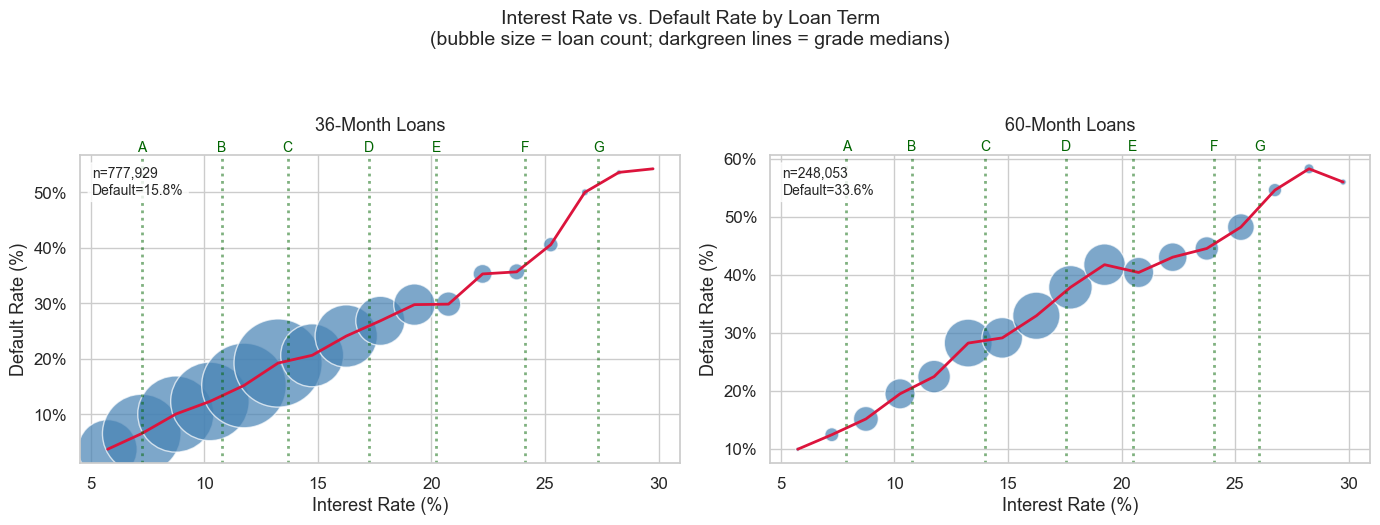

Summary by term:
                  n  default_rate  mean_rate
term_months                                 
36           777929        0.1579    12.0181
60           248053        0.3357    16.6694


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, term in zip(axes, [36, 60]):
    sub = df[df['term_months'] == term].copy()
    sub['b'] = pd.cut(sub['int_rate'], bins=np.arange(5, 32, 1.5), right=False)
    bt = (sub.groupby('b', observed=True)
          .agg(n=('default','count'), default_rate=('default','mean'))
          .reset_index())
    bt['mid'] = bt['b'].apply(lambda x: x.mid)
    bt = bt[bt['n'] >= 50]

    ax.scatter(bt['mid'], bt['default_rate']*100,
               s=bt['n']/30, alpha=0.7, color='steelblue', edgecolors='white')
    ax.plot(bt['mid'], bt['default_rate']*100, color='crimson', linewidth=2)

    for g in GRADE_ORDER:
        med = sub[sub['grade'] == g]['int_rate'].median() if (sub['grade'] == g).any() else None
        if med:
            ax.axvline(med, color='darkgreen', linestyle=':', alpha=0.5, linewidth=2)
            ax.text(med, bt['default_rate'].max()*100*1.02 + 2, g,
                    ha='center', fontsize=10, color='darkgreen')

    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlabel('Interest Rate (%)', fontsize=13)
    ax.set_ylabel('Default Rate (%)', fontsize=13)
    ax.set_title(f'{term}-Month Loans', fontsize=13, y=1.05)
    ax.text(0.02, 0.96, f'n={len(sub):,}\nDefault={sub["default"].mean():.1%}',
            transform=ax.transAxes, va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Interest Rate vs. Default Rate by Loan Term\n'
             '(bubble size = loan count; darkgreen lines = grade medians)', fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig05_term_int_rate_default.png', dpi=150, bbox_inches='tight')
plt.show()

print('Summary by term:')
print(df.groupby('term_months').agg(
    n=('default','count'), default_rate=('default','mean'), mean_rate=('int_rate','mean')
).round(4))

## A7. FICO Score Distribution by Grade + FICO vs Default Rate & Interest Rate

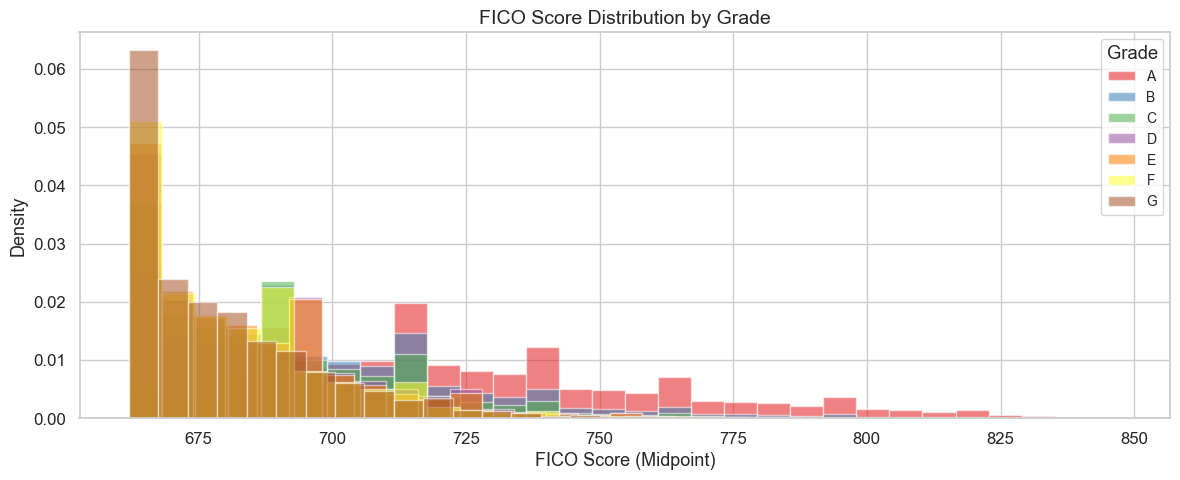

Median FICO by grade:
          count   mean   std    min    25%    50%    75%    max
grade                                                          
A      174351.0  724.6  36.3  662.0  697.0  717.0  747.0  847.5
B      299846.0  696.6  28.2  662.0  677.0  692.0  712.0  847.5
C      291855.0  688.9  24.0  662.0  672.0  682.0  702.0  847.5
D      153985.0  684.9  21.4  662.0  667.0  682.0  697.0  842.0
E       74318.0  683.6  20.4  662.0  667.0  677.0  692.0  842.0
F       25356.0  681.9  19.7  662.0  667.0  677.0  692.0  847.5
G        6271.0  680.3  18.7  662.0  667.0  677.0  687.0  827.0


In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
for g, color in zip(GRADE_ORDER, GRADE_PALETTE):
    ax.hist(df[df['grade'] == g]['fico_mid'], bins=30,
            alpha=0.55, color=color, label=g, density=True)
ax.set_xlabel('FICO Score (Midpoint)', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title('FICO Score Distribution by Grade', fontsize=14)
ax.legend(title='Grade', loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig07_fico_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

print('Median FICO by grade:')
print(df.groupby('grade')['fico_mid'].describe().round(1))

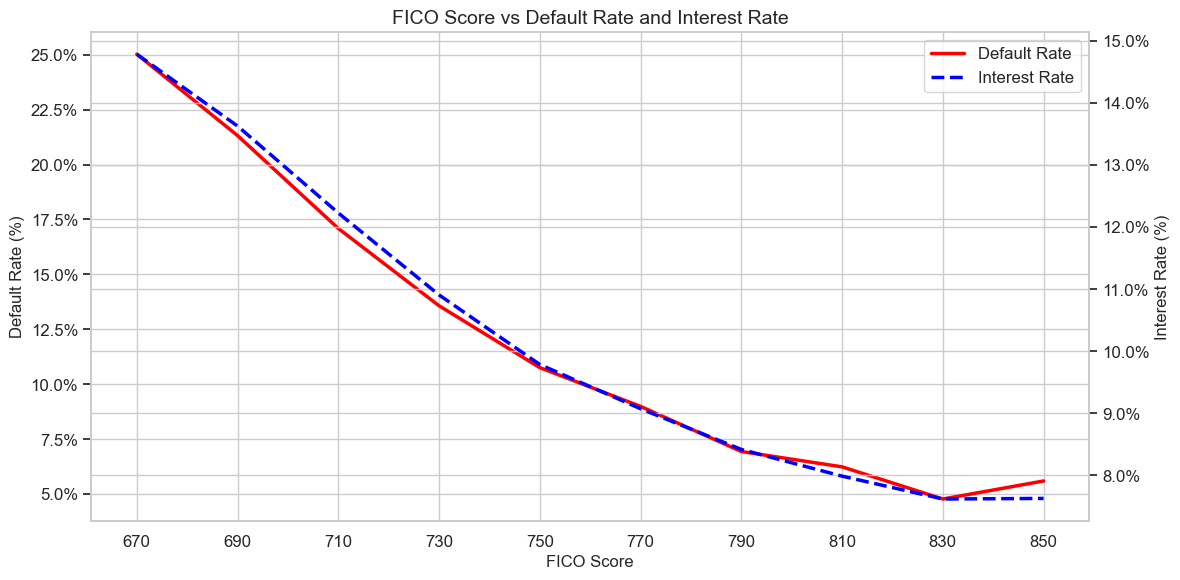

In [22]:
# FICO vs Interest rate & Default rate
fico_min = int(np.floor(df['fico_mid'].min() / 20) * 20)
fico_max = int(np.ceil(df['fico_mid'].max() / 20) * 20) + 20
fico_bins = np.arange(fico_min, fico_max + 1, 20)

df_plot = df.copy()
df_plot['fico_bin'] = pd.cut(df_plot['fico_mid'], bins=fico_bins, right=False)

df_plot['fico_bin_mid'] = df_plot['fico_bin'].apply(
    lambda x: x.left + 10 if pd.notnull(x) else np.nan
)

fico_stats = (
    df_plot.groupby('fico_bin_mid')
    .agg(
        n=('default', 'count'),
        default_rate=('default', 'mean'),
        int_rate=('int_rate', 'mean')
    )
    .reset_index()
)

# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Left: Default Rate
line1 = ax1.plot(
    fico_stats['fico_bin_mid'],
    fico_stats['default_rate'] * 100,
    linewidth=2.5,
    color='red',
    label='Default Rate'
)

ax1.set_xlabel('FICO Score', fontsize=12)
ax1.set_ylabel('Default Rate (%)', fontsize=12)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.grid(True)

# Right: Interest Rate
ax2 = ax1.twinx()

line2 = ax2.plot(
    fico_stats['fico_bin_mid'],
    fico_stats['int_rate'],
    linewidth=2.5,
    linestyle='--',
    color='blue',
    label='Interest Rate'
)

ax2.set_ylabel('Interest Rate (%)', fontsize=12)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

fico_x = fico_stats['fico_bin_mid'].tolist()
ax1.set_xticks(fico_x)
ax1.set_xticklabels([int(x) for x in fico_x])

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.title('FICO Score vs Default Rate and Interest Rate', fontsize=14)
plt.tight_layout()

plt.savefig(f'{FIGURE_DIR}/fig07_fico_int_default.png', dpi=150, bbox_inches='tight')
plt.show()

## A8.a. DTI Distribution by Default Status

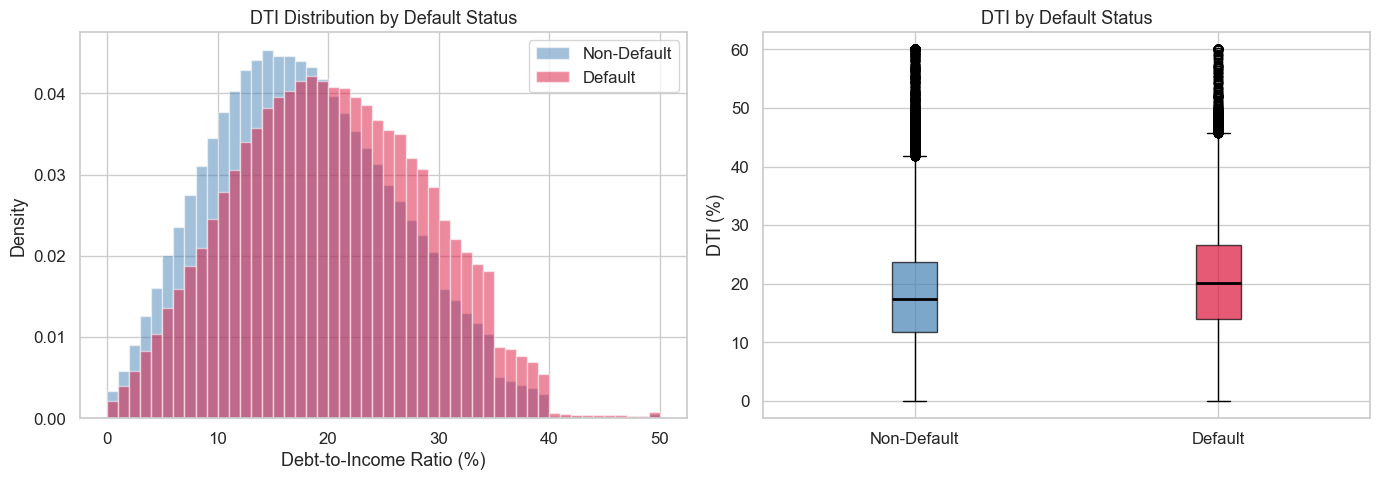

Mean DTI — non-default: 17.96%  |  default: 20.33%
Welch t-test: t=-111.89,  p=0.00e+00


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for status, color, label in [(0,'steelblue','Non-Default'), (1,'crimson','Default')]:
    ax.hist(df[df['default']==status]['dti'].clip(0, 50),
            bins=50, alpha=0.5, color=color, density=True, label=label)
ax.set_xlabel('Debt-to-Income Ratio (%)', fontsize=13); ax.set_ylabel('Density', fontsize=13)
ax.set_title('DTI Distribution by Default Status', fontsize=13); ax.legend()

ax = axes[1]
d0 = df[df['default']==0]['dti'].clip(0, 60)
d1 = df[df['default']==1]['dti'].clip(0, 60)
bp = ax.boxplot([d0, d1], labels=['Non-Default','Default'], patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('steelblue'); bp['boxes'][1].set_facecolor('crimson')
for box in bp['boxes']: box.set_alpha(0.7)
ax.set_ylabel('DTI (%)', fontsize=13); ax.set_title('DTI by Default Status', fontsize=13)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig08_dti_by_default.png', dpi=150, bbox_inches='tight')
plt.show()

t, p = stats.ttest_ind(d0, d1, equal_var=False)
print(f'Mean DTI — non-default: {d0.mean():.2f}%  |  default: {d1.mean():.2f}%')
print(f'Welch t-test: t={t:.2f},  p={p:.2e}')

## A8.b. DTI Distribution with Default and Interest Rates

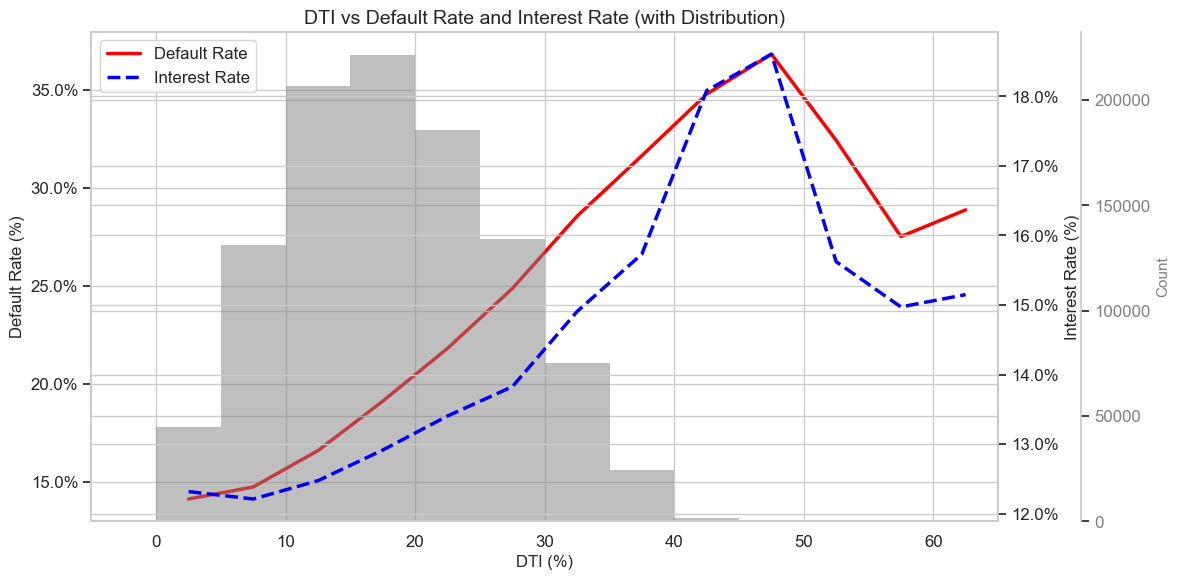

In [36]:
dti_min = int(np.floor(df['dti'].clip(0, 60).min() / 5) * 5)
dti_max = int(np.ceil(df['dti'].clip(0, 60).max() / 5) * 5) + 5
dti_bins = np.arange(dti_min, dti_max + 1, 5)

df_plot = df.copy()
df_plot['dti_bin'] = pd.cut(df_plot['dti'].clip(0, 60), bins=dti_bins, right=False)

# bin midpoint
df_plot['dti_bin_mid'] = df_plot['dti_bin'].apply(
    lambda x: x.left + 2.5 if pd.notnull(x) else np.nan
)

# -----------------------------
# 2) 집계
# -----------------------------
dti_stats = (
    df_plot.groupby('dti_bin_mid')
    .agg(
        n=('default', 'count'),
        default_rate=('default', 'mean'),
        int_rate=('int_rate', 'mean')
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 6))

# ===== Histogram (background) =====
ax3 = ax1.twinx() 

ax3.hist(
    df_plot['dti'].clip(0, 60),
    bins=dti_bins,
    color='gray',
    alpha=0.5, 
    edgecolor='none'
)

ax3.set_ylabel('Count', fontsize=11, color='gray')
ax3.tick_params(axis='y', labelcolor='gray')

ax3.spines['right'].set_position(('outward', 60))

line1 = ax1.plot(
    dti_stats['dti_bin_mid'],
    dti_stats['default_rate'] * 100,
    linewidth=2.5,
    color='red',
    label='Default Rate'
)

ax1.set_xlabel('DTI (%)', fontsize=12)
ax1.set_ylabel('Default Rate (%)', fontsize=12)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.grid(True)

ax2 = ax1.twinx()

line2 = ax2.plot(
    dti_stats['dti_bin_mid'],
    dti_stats['int_rate'],
    linewidth=2.5,
    linestyle='--',
    color='blue',
    label='Interest Rate'
)

ax2.set_ylabel('Interest Rate (%)', fontsize=12)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

ax1.set_xlim(-5, 65)
ax1.set_xticks(np.arange(0, 61, 10))

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')


plt.title('DTI vs Default Rate and Interest Rate (with Distribution)', fontsize=14)
plt.tight_layout()

plt.savefig(f'{FIGURE_DIR}/fig08_dti_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

## A9. Interest Rate and Default Rate by Loan Purpose

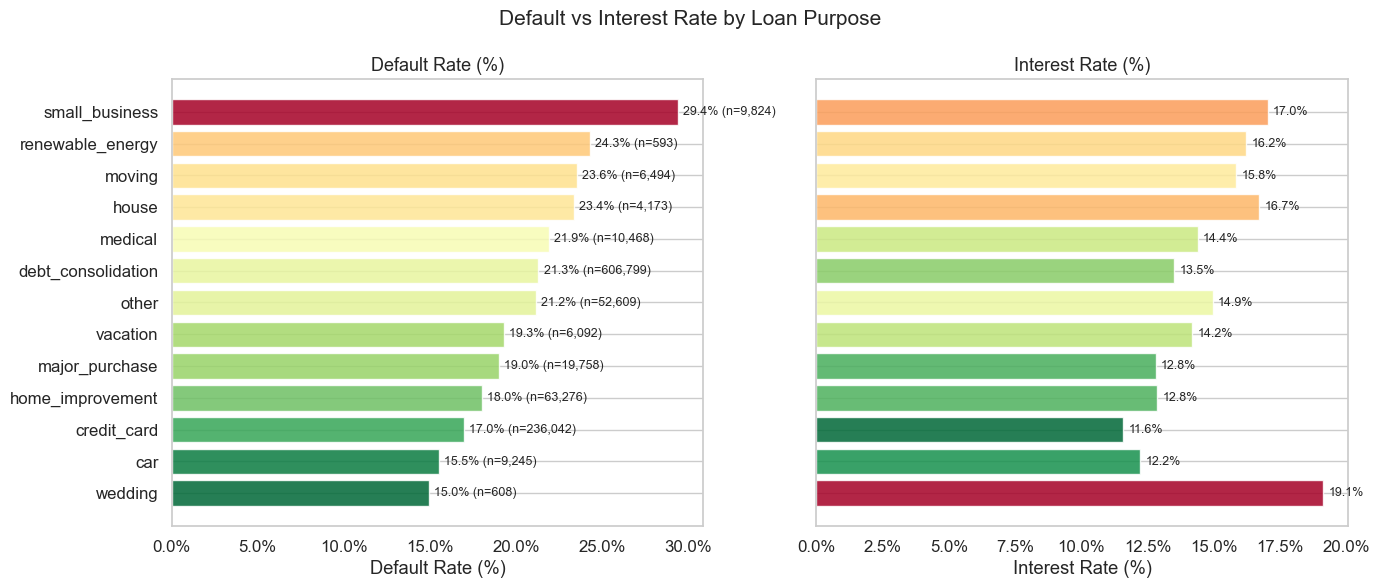

In [38]:
purpose_stats = (
    df.groupby('purpose')
    .agg(
        n=('default', 'count'),
        default_rate=('default', 'mean'),
        int_rate=('int_rate', 'mean')
    )
    .query('n >= 200')
    .sort_values('default_rate', ascending=True)
)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ===== Left: Default Rate =====
norm1 = plt.Normalize(purpose_stats['default_rate'].min(),
                      purpose_stats['default_rate'].max())
colors1 = plt.cm.RdYlGn_r(norm1(purpose_stats['default_rate'].values))

bars1 = axes[0].barh(
    purpose_stats.index,
    purpose_stats['default_rate'] * 100,
    color=colors1,
    alpha=0.85,
    edgecolor='white'
)

for bar, (_, row) in zip(bars1, purpose_stats.iterrows()):
    axes[0].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"{row['default_rate']*100:.1f}% (n={int(row['n']):,})",
        va='center',
        fontsize=9
    )

axes[0].set_title('Default Rate (%)', fontsize=13)
axes[0].set_xlabel('Default Rate (%)')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].grid(axis='x')

# ===== Right: Interest Rate =====
norm2 = plt.Normalize(purpose_stats['int_rate'].min(),
                      purpose_stats['int_rate'].max())
colors2 = plt.cm.RdYlGn_r(norm2(purpose_stats['int_rate'].values))

bars2 = axes[1].barh(
    purpose_stats.index,
    purpose_stats['int_rate'],
    color=colors2,
    alpha=0.85,
    edgecolor='white'
)

for bar, (_, row) in zip(bars2, purpose_stats.iterrows()):
    axes[1].text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height()/2,
        f"{row['int_rate']:.1f}%",
        va='center',
        fontsize=9
    )

axes[1].set_title('Interest Rate (%)', fontsize=13)
axes[1].set_xlabel('Interest Rate (%)')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].grid(axis='x')

# --- Final layout ---
fig.suptitle('Default vs Interest Rate by Loan Purpose', fontsize=15)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig09_purpose_default_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## A10. Vintage Analysis — Default Rate & Interest Rate by Issue Year and Grade

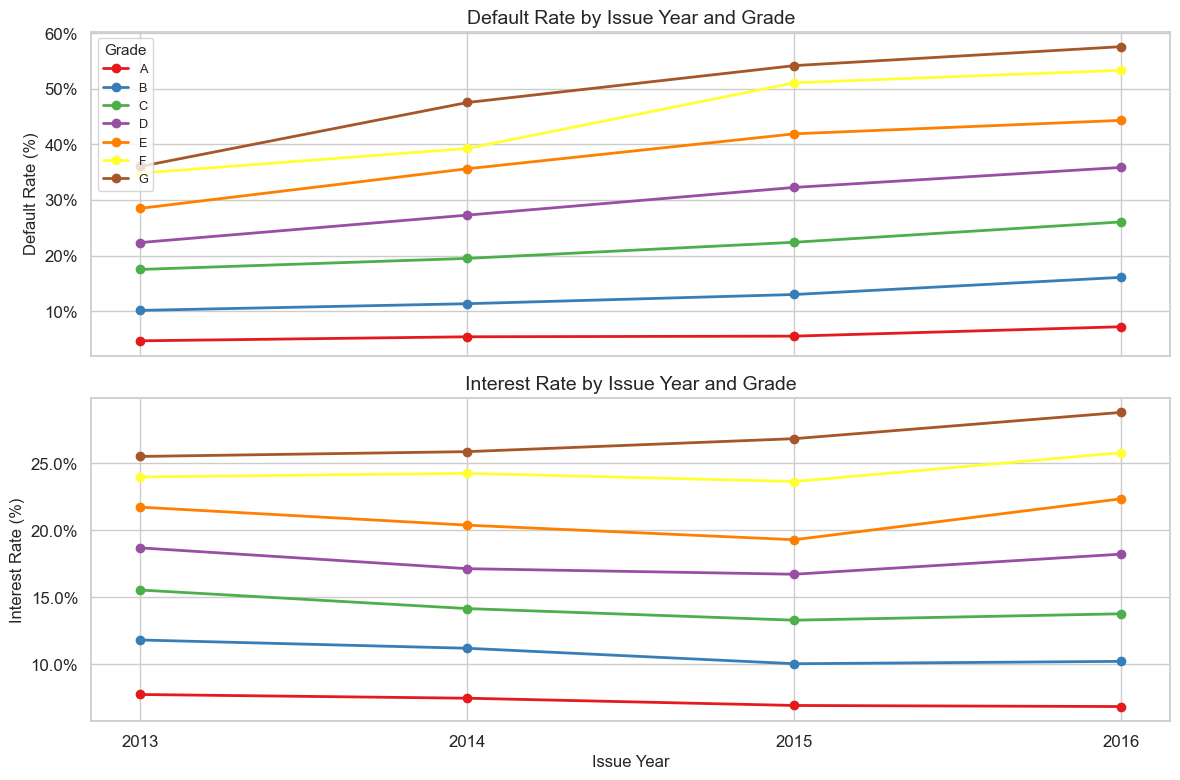

In [40]:
# --- Default rate (top) ---
vintage_default = df.groupby(['issue_year', 'grade'])['default'].mean().unstack()
vintage_default = vintage_default[[g for g in GRADE_ORDER if g in vintage_default.columns]]

# --- Interest rate (bottom) ---
vintage_int = df.groupby(['issue_year', 'grade'])['int_rate'].mean().unstack()
vintage_int = vintage_int[[g for g in GRADE_ORDER if g in vintage_int.columns]]

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# ===== Top: Default Rate =====
for g, color in zip(GRADE_ORDER, GRADE_PALETTE):
    if g in vintage_default.columns:
        axes[0].plot(
            vintage_default.index,
            vintage_default[g] * 100,
            marker='o',
            color=color,
            linewidth=2,
            label=g
        )

axes[0].set_ylabel('Default Rate (%)', fontsize=12)
axes[0].set_title('Default Rate by Issue Year and Grade', fontsize=14)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].legend(title='Grade', loc='upper left', fontsize='x-small', title_fontsize='small')
axes[0].grid(True)

# ===== Bottom: Interest Rate =====
for g, color in zip(GRADE_ORDER, GRADE_PALETTE):
    if g in vintage_int.columns:
        axes[1].plot(
            vintage_int.index,
            vintage_int[g],
            marker='o',
            color=color,
            linewidth=2,
            label=g
        )

axes[1].set_xticks(sorted(df['issue_year'].unique()))
axes[1].set_xlabel('Issue Year', fontsize=12)
axes[1].set_ylabel('Interest Rate (%)', fontsize=12)
axes[1].set_title('Interest Rate by Issue Year and Grade', fontsize=14)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig10_vintage_default_int.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
print(pd.concat([(100 * vintage_default).transpose().sort_index(ascending=False).round(2),
                vintage_int.transpose().sort_index(ascending=False).round(2)],
                axis=1, keys=['default', 'int_rate']))

           default                      int_rate                     
issue_year    2013   2014   2015   2016     2013   2014   2015   2016
grade                                                                
G            36.05  47.54  54.17  57.58    25.51  25.87  26.83  28.80
F            34.85  39.28  51.08  53.34    23.98  24.25  23.64  25.79
E            28.52  35.63  41.91  44.33    21.72  20.38  19.29  22.35
D            22.37  27.30  32.28  35.87    18.69  17.13  16.72  18.22
C            17.53  19.52  22.42  26.07    15.54  14.16  13.29  13.77
B            10.17  11.37  13.03  16.11    11.81  11.19  10.04  10.22
A             4.70   5.43   5.54   7.23     7.74   7.47   6.92   6.85


## A11. Correlation Heatmap

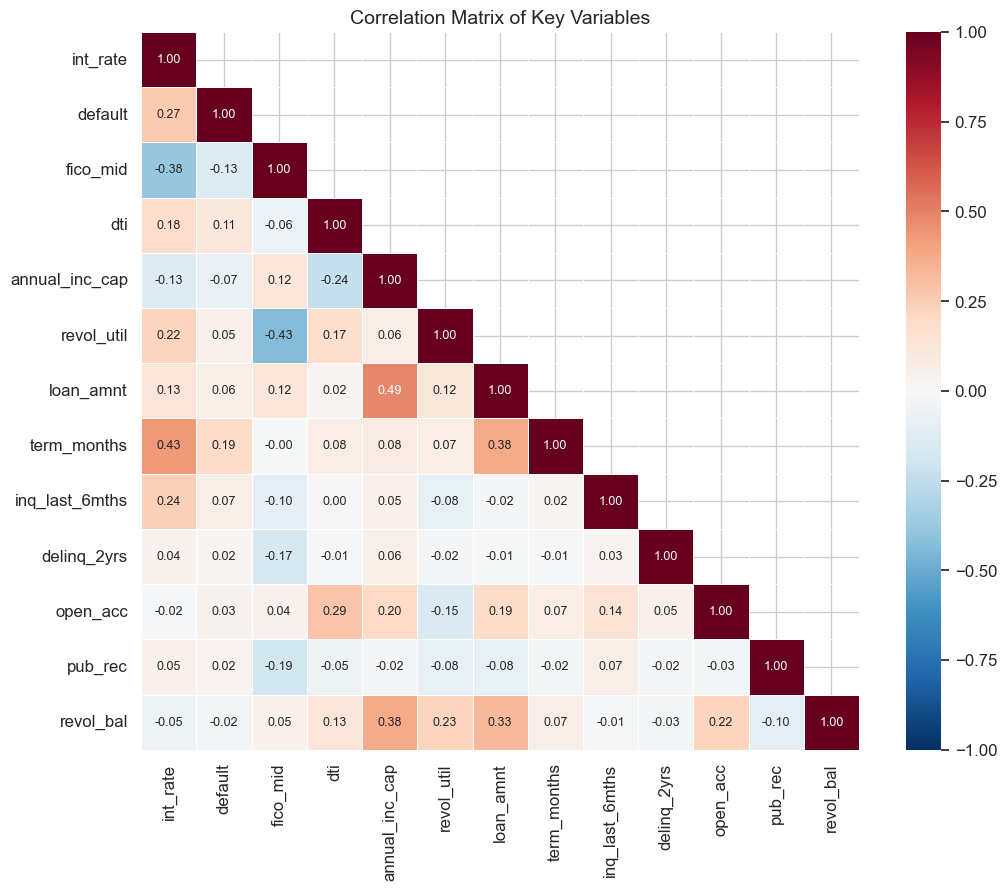

Correlation with default & interest rate (sorted):
                default  int_rate
default          1.0000    0.2651
int_rate         0.2651    1.0000
term_months      0.1899    0.4321
dti              0.1119    0.1803
inq_last_6mths   0.0670    0.2360
loan_amnt        0.0585    0.1256
revol_util       0.0510    0.2245
open_acc         0.0334   -0.0156
pub_rec          0.0245    0.0538
delinq_2yrs      0.0169    0.0398
revol_bal       -0.0247   -0.0479
annual_inc_cap  -0.0659   -0.1282
fico_mid        -0.1274   -0.3838


In [43]:
corr_vars = [
    'int_rate', 'default', 'fico_mid', 'dti', 'annual_inc_cap',
    'revol_util', 'loan_amnt', 'term_months', 'inq_last_6mths',
    'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal'
]
corr_vars = [v for v in corr_vars if v in df.columns]
corr_matrix = df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, square=True, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Correlation Matrix of Key Variables', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig12_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation with default & interest rate (sorted):')
print(pd.concat([corr_matrix['default'].sort_values(ascending=False).round(4),
                 corr_matrix['int_rate'].sort_values(ascending=False).round(4)],
                axis=1, keys=['default', 'int_rate']))

## A12. Within Grade Rate Variation (Treatment Overlap Preview)

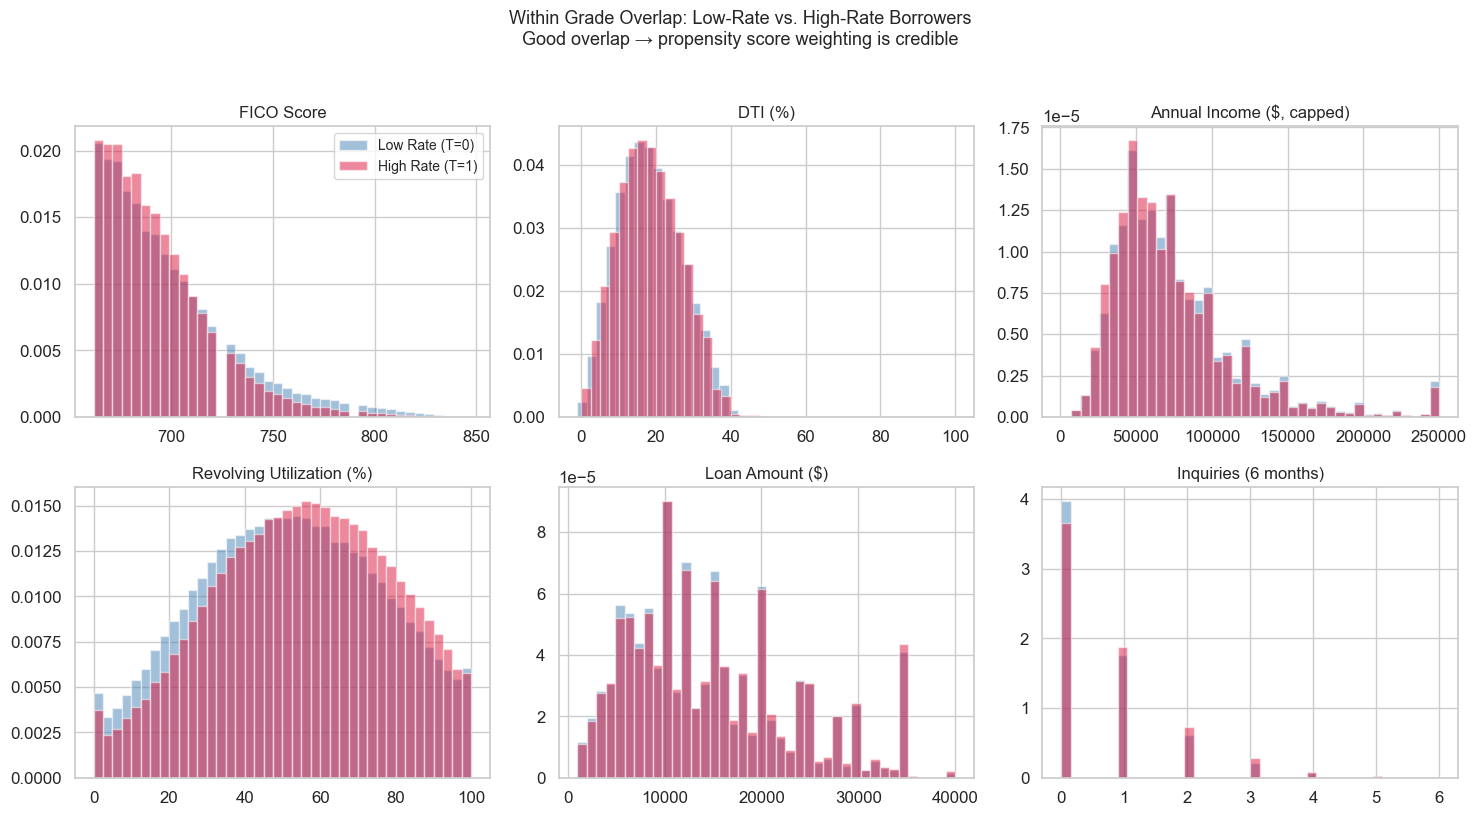

Standardized Mean Differences (high_rate preview vs. low_rate):
-------------------------------------------------------
FICO Score                           SMD = -0.1537
DTI (%)                              SMD = +0.0077
Annual Income ($, capped)            SMD = -0.0580
Revolving Utilization (%)            SMD = +0.1321
Loan Amount ($)                      SMD = +0.0298
Inquiries (6 months)                 SMD = +0.1046


In [45]:
# Check that within each grade, interest rates vary enough to support
# a high-vs-low treatment split — and that the two groups look similar on observables.
grade_medians = df.groupby('grade')['int_rate'].median()
df['high_rate_preview'] = (df['int_rate'] > df['grade'].map(grade_medians)).astype(int)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
vars_check = [
    ('fico_mid', 'FICO Score'),
    ('dti', 'DTI (%)'),
    ('annual_inc_cap', 'Annual Income ($, capped)'),
    ('revol_util', 'Revolving Utilization (%)'),
    ('loan_amnt', 'Loan Amount ($)'),
    ('inq_last_6mths', 'Inquiries (6 months)')
]

for ax, (var, label) in zip(axes.flatten(), vars_check):
    for t, color, lbl in [(0,'steelblue','Low Rate (T=0)'),(1,'crimson','High Rate (T=1)')]:
        ax.hist(df[df['high_rate_preview']==t][var].dropna(),
                bins=40, alpha=0.5, color=color, density=True, label=lbl)
    ax.set_title(label, fontsize=12) 
    if var=='fico_mid':
        ax.legend(fontsize=10)
    

plt.suptitle('Within Grade Overlap: Low-Rate vs. High-Rate Borrowers\n'
             'Good overlap → propensity score weighting is credible',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig11_treatment_overlap_preview.png', dpi=150, bbox_inches='tight')
plt.show()

print('Standardized Mean Differences (high_rate preview vs. low_rate):')
print('-' * 55)
for var, label in vars_check:
    m1 = df[df['high_rate_preview']==1][var].mean()
    m0 = df[df['high_rate_preview']==0][var].mean()
    sd = df[var].std()
    smd = (m1 - m0) / sd if sd > 0 else np.nan
    print(f'{label:35s}  SMD = {smd:+.4f}')

df.drop(columns=['high_rate_preview'], inplace=True)

### EDA Summary

Key findings that inform feature selection:
1. **Grade (or sub-grade) drives most of the rate–default correlation** — within-grade variation is the basis for causal identification.
2. **Term independently predicts default** at the same rate level (60-month loans default more).
3. **FICO and DTI are the strongest credit-quality signals** after grade; high correlation with both rate and default → must be controlled.
4. **Purpose matters** (small business >> debt consolidation in default rate) → include as control.
5. **Between 2013 and 2016, default rates increased steadily** across all credit grades.
6. **Inquiry count, annual income, loan amount, and revolving utilization** are meaningfully correlated with default.
7. **Within-grade overlap is good** (SMD < 0.1 for most covariates) → propensity score approach is credible.

---
# Part B — Feature Selection

Use correlation analysis and gradient-boosted permutation importance to rank candidate features and drop near-zero-variance or highly collinear ones.

In [48]:
print(f'Numeric features:\n{df.select_dtypes(include=['float']).dtypes}')

CANDIDATE_NUMERIC = [
    'loan_amnt', 'dti', 'delinq_2yrs', 'inq_last_6mths', 
    'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal', 
    'revol_util', 'total_acc', 'emp_length_num', 'fico_mid', 
    'annual_inc_cap'
]

Numeric features:
loan_amnt                 float64
funded_amnt               float64
int_rate                  float64
annual_inc                float64
dti                       float64
delinq_2yrs               float64
fico_range_low            float64
fico_range_high           float64
inq_last_6mths            float64
mths_since_last_delinq    float64
open_acc                  float64
pub_rec                   float64
revol_bal                 float64
revol_util                float64
total_acc                 float64
emp_length_num            float64
fico_mid                  float64
annual_inc_cap            float64
dtype: object


## Step 1: Variance Filter (near-zero variance features lack information)

In [50]:
print(f'Candidates before variance filter: {len(CANDIDATE_NUMERIC)}')
variances = df[CANDIDATE_NUMERIC].var()
low_var = variances[variances < 0.01].index.tolist()
print(f'Dropping low-variance features: {low_var}')
candidates = [c for c in CANDIDATE_NUMERIC if c not in low_var]

print(f'Candidates after variance filter: {len(candidates)}')

Candidates before variance filter: 13
Dropping low-variance features: []
Candidates after variance filter: 13


## Step 2: Correlation with Default

In [52]:
corr_with_default = (
    df[candidates + ['default']].corr()['default']
    .drop('default').abs()
    .sort_values(ascending=False)
)
print('Absolute Correlation with default — numeric candidates:\n')
print(corr_with_default.round(4))

Absolute Correlation with default — numeric candidates:

fico_mid                  0.1274
dti                       0.1119
inq_last_6mths            0.0670
annual_inc_cap            0.0659
loan_amnt                 0.0585
revol_util                0.0510
open_acc                  0.0334
emp_length_num            0.0272
revol_bal                 0.0247
pub_rec                   0.0245
delinq_2yrs               0.0169
mths_since_last_delinq    0.0156
total_acc                 0.0035
Name: default, dtype: float64


## Step 3: Pairwise Collinearity Check

In [54]:
def print_high_correlations(df, upper=0.999, lower=0.3):
    num_df = df.select_dtypes(include=np.number)
    corr = num_df.corr().abs()
    
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    high_corr = (
        corr.where(mask)
            .stack()
            .reset_index()
    )
    
    high_corr.columns = ['Feature_1', 'Feature_2', 'Correlation']

    high_corr['abs_corr'] = high_corr['Correlation'].abs()
    
    high_corr = high_corr[(high_corr['abs_corr'] <= upper) & (high_corr['Correlation'] >= lower)]
    high_corr = high_corr.sort_values('abs_corr', ascending=False)
    
    print(high_corr[['Feature_1', 'Feature_2', 'Correlation']].reset_index(drop=True))

In [55]:
# `open_acc` and `total_acc` have correlation of 0.7. 
# `open_acc` captures current credit exposure
# `total_acc` reflects the borrower’s overall credit history depth
# Decided to retain both values as they provide complementary risk information.
print_high_correlations(df[candidates], upper=0.9999, lower=0.2)

                 Feature_1               Feature_2  Correlation
0                 open_acc               total_acc     0.699373
1                loan_amnt          annual_inc_cap     0.487530
2               revol_util                fico_mid     0.432331
3                revol_bal          annual_inc_cap     0.375733
4              delinq_2yrs  mths_since_last_delinq     0.370999
5                loan_amnt               revol_bal     0.326141
6   mths_since_last_delinq                fico_mid     0.303446
7                      dti                open_acc     0.286328
8                total_acc          annual_inc_cap     0.267380
9                      dti          annual_inc_cap     0.239760
10               revol_bal              revol_util     0.225016
11                     dti               total_acc     0.220939
12                open_acc               revol_bal     0.219649
13               loan_amnt               total_acc     0.213613
14                open_acc          annu

In [56]:
print(f'Candidates before collinearity filter: {len(candidates)}')
corr_mat = df[candidates].corr().abs()
upper    = corr_mat.where(np.triu(np.ones_like(corr_mat, dtype=bool), k=1))
high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.85
]

to_drop_collinear = set()
for f1, f2, r in high_corr_pairs:
    keep = f1 if corr_with_default.get(f1, 0) >= corr_with_default.get(f2, 0) else f2
    drop = f2 if keep == f1 else f1
    to_drop_collinear.add(drop)
    print(f'  |r({f1}, {f2})| = {r:.3f}  → keep={keep}, drop={drop}')

candidates = [c for c in candidates if c not in to_drop_collinear]
print(f'Candidates after collinearity filter: {len(candidates)}')

Candidates before collinearity filter: 13
Candidates after collinearity filter: 13


## Step 4: Gradient-boosted Feature Importance

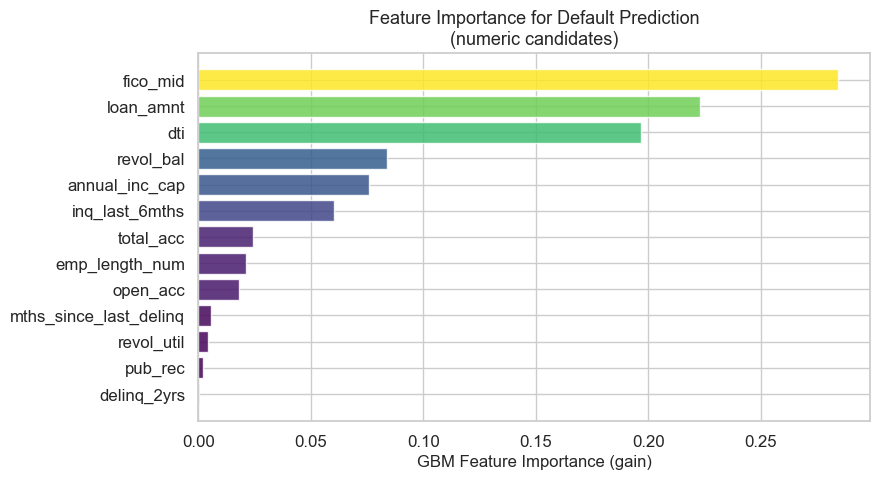

fico_mid                  0.2845
loan_amnt                 0.2229
dti                       0.1968
revol_bal                 0.0837
annual_inc_cap            0.0760
inq_last_6mths            0.0603
total_acc                 0.0242
emp_length_num            0.0213
open_acc                  0.0182
mths_since_last_delinq    0.0054
revol_util                0.0041
pub_rec                   0.0022
delinq_2yrs               0.0003
dtype: float64


In [58]:
# Use a quick GBM to rank the remaining numeric candidates by permutation importance.
feat_df = df[candidates + ['default']].dropna()
X_feat  = feat_df[candidates].values
y_feat  = feat_df['default'].values

gbm_sel = GradientBoostingClassifier(n_estimators=100, max_depth=3,
                                      learning_rate=0.1, random_state=42)
gbm_sel.fit(X_feat, y_feat)

imp = pd.Series(gbm_sel.feature_importances_, index=candidates)\
        .sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
norm = plt.Normalize(imp.min(), imp.max())
colors = plt.cm.viridis(norm(imp.values))
ax.barh(imp.index[::-1], imp.values[::-1], color=colors[::-1], alpha=0.85, edgecolor='white')
ax.set_xlabel('GBM Feature Importance (gain)', fontsize=12)
ax.set_title('Feature Importance for Default Prediction\n(numeric candidates)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig13_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(imp.round(4))

## Step 5: Final Numeric Feature Set
- Keep all features with importance >= 0.01 AND |r default| >= 0.02.

In [60]:
KEEP_ALWAYS = ['fico_mid', 'dti', 'inq_last_6mths', 'annual_inc_cap', 'loan_amnt', 'revol_util']

selected_by_importance = imp[imp >= 0.01].index.tolist()
SELECTED_NUMERIC = list(set(KEEP_ALWAYS + selected_by_importance))
SELECTED_NUMERIC = [c for c in SELECTED_NUMERIC if c in df.columns]

print(f'Excluded numeric features: {[x for x in candidates if x not in SELECTED_NUMERIC]}')
print(f'\nSelected numeric features ({len(SELECTED_NUMERIC)}):')
print(SELECTED_NUMERIC)

Excluded numeric features: ['delinq_2yrs', 'mths_since_last_delinq', 'pub_rec']

Selected numeric features (10):
['inq_last_6mths', 'revol_bal', 'open_acc', 'annual_inc_cap', 'loan_amnt', 'dti', 'total_acc', 'emp_length_num', 'fico_mid', 'revol_util']


## Step 6: Categorical Features to One-Hot Encode
- `purpose`: Large between-group default variation justified by EDA
- `home_ownership`, `verification_status`, `ever_delinq`: typically informative for creidtworthiness.
- `term_months` and `issue_year` showed close relationship with default rate in the EDA aobve.

In [62]:
# --- Categorical features to one-hot encode ---
print(f'Categorical features:\n{df.select_dtypes(include=['int', 'object']).dtypes}\n')

NOMINAL_FEATURES = ['home_ownership', 'verification_status', 'purpose']
ORDINAL_FEATURES = ['term_months', 'issue_year']
BOOL_FEATURES = ['ever_delinq']

for col in NOMINAL_FEATURES + ORDINAL_FEATURES + BOOL_FEATURES:
    vc = df[col].value_counts()
    print(f'{col} ({len(vc)} levels):')
    print(vc.to_string())
    print()

Categorical features:
id                       str
term                     str
grade                    str
sub_grade                str
emp_length               str
home_ownership           str
verification_status      str
loan_status              str
purpose                  str
addr_state               str
application_type         str
issue_year             Int64
term_months            int64
ever_delinq            int64
default                int64
dtype: object

home_ownership (4 levels):
home_ownership
MORTGAGE    509305
RENT        406899
OWN         109713
ANY             65

verification_status (3 levels):
verification_status
Source Verified    409271
Verified           325883
Not Verified       290828

purpose (14 levels):
purpose
debt_consolidation    606799
credit_card           236042
home_improvement       63276
other                  52609
major_purchase         19758
medical                10468
small_business          9824
car                     9245
moving           

---
# Part C — Feature Engineering

Build the final modeling dataset used by all downstream notebooks.

## C1. Annual income: log-transform

In [65]:
mdf = df.copy()

mdf['log_annual_inc'] = np.log1p(mdf['annual_inc_cap'])
print('Log-income: mean={:.3f}, std={:.3f}'.format(
    mdf['log_annual_inc'].mean(), mdf['log_annual_inc'].std()))

SELECTED_NUMERIC2 = ['log_annual_inc' if x == 'annual_inc_cap' else x for x in SELECTED_NUMERIC]

Log-income: mean=11.084, std=0.521


## C2. One-hot encode nominal features

In [67]:
# Remove small number nominal feature values (home_ownership = 'ANY')
# Merge small number nominal feature values (purpose.isin(['moving', 'vacation', 'house', 'wedding', 'renewable_energy', 'educational'])
mdf = mdf[mdf['home_ownership'] != 'ANY'].copy()

purpose_map = {
    # debt
    "debt_consolidation": "debt",
    "credit_card": "debt",

    # home / asset
    "home_improvement": "home_asset",
    "house": "home_asset",
    "moving": "home_asset",

    # planned_purchase
    "major_purchase": "planned_purchase",
    "car": "planned_purchase",

    # business
    "small_business": "small_business",

    # distress
    "medical": "medical",

    # discretionary
    "vacation": "other",
    "wedding": "other",
    "renewable_energy": "other",
    "other": "other",
    "educational": "other"
}


mdf['purpose'] = mdf['purpose'].map(purpose_map)

mdf = pd.get_dummies(
    mdf,
    columns=NOMINAL_FEATURES,
    drop_first=True,
    dtype=int
)
cat_cols = [c for c in mdf.columns if any(
    c.startswith(p + '_') for p in NOMINAL_FEATURES
)]
print(f'One-hot columns ({len(cat_cols)}): {cat_cols} ...')

One-hot columns (9): ['home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Source Verified', 'verification_status_Verified', 'purpose_home_asset', 'purpose_medical', 'purpose_other', 'purpose_planned_purchase', 'purpose_small_business'] ...


## C3. Ordinal encode ordinal features

In [69]:
ord_mapping = {
    'term_months': [36, 60],
    'issue_year': [2013, 2014, 2015, 2016]
}

for col, order in ord_mapping.items():
    enc = OrdinalEncoder(categories=[order])
    mdf[col + '_encoded'] = enc.fit_transform(mdf[[col]])

ORDINAL_FEATURES2 = [col + '_encoded' for col in ORDINAL_FEATURES]

## C4. Grade and Sub-grade: ordinal encoding

In [71]:
GRADE_ORDER_MAP = {g: i for i, g in enumerate(GRADE_ORDER)}
SUBGRADE_MAP = {sg: i for i, sg in enumerate(SUBGRADE_ORDER)}

mdf['grade_num']    = mdf['grade'].map(GRADE_ORDER_MAP)
mdf['subgrade_num'] = mdf['sub_grade'].map(SUBGRADE_MAP)

print('grade_num range   :', mdf['grade_num'].min(), '–', mdf['grade_num'].max())
print('subgrade_num range:', mdf['subgrade_num'].min(), '–', mdf['subgrade_num'].max())

grade_num range   : 0 – 6
subgrade_num range: 0 – 34


## C5. Treatment variables
1. Primary treatment: above-median interest rate WITHIN grade
   - Grade captures broad credit-tier confounding within-grade rate variation is driven by finer scoring and is more plausibly quasi-random conditional on observables.
2. Secondary treatment: above-median rate within SUB-GRADE (for boundary analysis)
3. Continuous treatment: deviation from grade median (used in DML)

In [73]:
# Primary Treatment
grade_medians = mdf.groupby('grade')['int_rate'].median()
mdf['grade_median_rate'] = mdf['grade'].map(grade_medians)
mdf['high_rate'] = (mdf['int_rate'] > mdf['grade_median_rate']).astype(int)

# Secondary Treatment
sg_medians = mdf.groupby('sub_grade')['int_rate'].median()
mdf['subgrade_median_rate'] = mdf['sub_grade'].map(sg_medians)
mdf['high_rate_subgrade']   = (mdf['int_rate'] > mdf['subgrade_median_rate']).astype(int)

# Continuous Treatment
mdf['rate_dev'] = mdf['int_rate'] - mdf['grade_median_rate']

print('Treatment distribution by grade:')
print(mdf.groupby('grade')['high_rate'].agg(['mean','count']).round(4))
print(f'\nOverall treated fraction: {mdf["high_rate"].mean():.4f}')

Treatment distribution by grade:
         mean   count
grade                
A      0.4606  174341
B      0.4931  299820
C      0.4828  291840
D      0.4031  153978
E      0.4700   74312
F      0.4882   25356
G      0.4960    6270

Overall treated fraction: 0.4694


## C6. Build final covariate list

In [75]:
COVARIATES = SELECTED_NUMERIC2 + cat_cols + ORDINAL_FEATURES2 + BOOL_FEATURES + ['grade_num', 'subgrade_num']

print(f'Total covariates: {len(COVARIATES)}')
print(COVARIATES)

Total covariates: 24
['inq_last_6mths', 'revol_bal', 'open_acc', 'log_annual_inc', 'loan_amnt', 'dti', 'total_acc', 'emp_length_num', 'fico_mid', 'revol_util', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Source Verified', 'verification_status_Verified', 'purpose_home_asset', 'purpose_medical', 'purpose_other', 'purpose_planned_purchase', 'purpose_small_business', 'term_months_encoded', 'issue_year_encoded', 'ever_delinq', 'grade_num', 'subgrade_num']


## C6. Drop rows missing any modeling column

In [77]:
model_cols = ['default', 'int_rate', 'high_rate', 'high_rate_subgrade', 'rate_dev'] + COVARIATES

before = len(mdf)
mdf = mdf[model_cols].dropna()
print(f'Rows dropped (any missing in model cols): {before - len(mdf):,}')
print(f'Final modeling dataset: {mdf.shape}')
print(f'Default rate           : {mdf["default"].mean():.4f}')
print(f'Treated fraction       : {mdf["high_rate"].mean():.4f}')

Rows dropped (any missing in model cols): 0
Final modeling dataset: (1025917, 29)
Default rate           : 0.2009
Treated fraction       : 0.4694


## C7. StandardScaler Numeric Features

In [79]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), SELECTED_NUMERIC2),
        ("cat", "passthrough", [x for x in mdf.columns if x not in SELECTED_NUMERIC2])
    ],
    verbose_feature_names_out =False
)

mdf = pd.DataFrame(
    preprocess.fit_transform(mdf),
    columns = preprocess.get_feature_names_out(),
    index = mdf.index
)            

In [80]:
# Save modeling dataset and metadata
mdf.to_parquet(f'{DATA_DIR}/accepted_modeling.parquet', index=False)

meta = {
    'SELECTED_NUMERIC': SELECTED_NUMERIC2,
    'SELECTED_NOMINAL': cat_cols + BOOL_FEATURES,
    'SELECTED_ORDINAL': ORDINAL_FEATURES2,
    'COVARIATES': COVARIATES,
    'GRADE_ORDER': GRADE_ORDER,
    'DEFAULT_STATUSES': [
        'Charged Off', 'Default',
        'Does not meet the credit policy. Status:Charged Off'
    ]
}
with open(f'{DATA_DIR}/meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved: accepted_modeling.parquet')
print('Saved: meta.json')
print()
print('Column inventory:')
print(mdf.dtypes.to_string())

Saved: accepted_modeling.parquet
Saved: meta.json

Column inventory:
inq_last_6mths                         float64
revol_bal                              float64
open_acc                               float64
log_annual_inc                         float64
loan_amnt                              float64
dti                                    float64
total_acc                              float64
emp_length_num                         float64
fico_mid                               float64
revol_util                             float64
default                                float64
int_rate                               float64
high_rate                              float64
high_rate_subgrade                     float64
rate_dev                               float64
home_ownership_OWN                     float64
home_ownership_RENT                    float64
verification_status_Source Verified    float64
verification_status_Verified           float64
purpose_home_asset                    

## Feature Engineering Summary

| Feature | Transformation | Motivation |
|---|---|---|
| `log_annual_inc` | log(1 + annual_inc_cap) | Right-skewed income → log scale improves linearity |
| `ever_delinq` | Binary flag from `mths_since_last_delinq` | Summarises delinquency history in one bit |
| `grade_num` | Ordinal 0–6 | Enables smooth grade trend in regression models |
| `subgrade_num` | Ordinal 0–34 | Fine-grained credit tier used in boundary analysis |
| `high_rate` | Binary: int_rate > grade median | **Primary treatment variable** for IPW/AIPW |
| `high_rate_subgrade` | Binary: int_rate > sub-grade median | Secondary treatment for boundary analysis |
| `rate_dev` | int_rate − grade median | **Continuous treatment** for DML |
| One-hot dummies | `home_ownership`, `verification_status`, `purpose`, `application_type` | Capture nominal heterogeneity in approval and default rates |
| Ordinal Encoding | `term_months`, `issue_year`| Capture ordinal heterogeneity in approval and default rates |